# 05 - Comparacao: Amostra 30% vs 100% dos Dados

Este notebook executa o pipeline completo com 30% dos dados e compara com os resultados de 100%.

In [2]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

from src.data_prep import carregar_dados_enem, limpar_dados_enem, agregar_por_escola, criar_features_adicionais
from src.clustering import kmeans_multi_seed
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette("husl")
print('OK')

OK


## 1. Executar Pipeline com 30% dos Dados

In [3]:
# Configuracoes para 30%
DATA_RAW = project_root / '..' / 'microdados_enem_2024' / 'DADOS' / 'RESULTADOS_2024.csv'
DATA_PROCESSED = project_root / 'data' / 'processed'

FRAC_30 = 0.3
MIN_ALUNOS = 10
SEED = 42

print('=== PROCESSANDO 30% DOS DADOS ===')
print(f'Amostra: {FRAC_30*100:.0f}%')

=== PROCESSANDO 30% DOS DADOS ===
Amostra: 30%


In [6]:
# Carregar 30%
df_alunos_30 = carregar_dados_enem(DATA_RAW, amostra=FRAC_30)
print(f'Alunos carregados: {len(df_alunos_30):,}')

Carregando dados de: C:\Users\leofs\Documents\ciencia_de_dados_2\enem_clustering\..\microdados_enem_2024\DADOS\RESULTADOS_2024.csv
Aplicando amostragem de 30.0%
Dados carregados: 1299883 linhas, 42 colunas
Alunos carregados: 1,299,883


In [8]:
# Limpar e agregar
df_alunos_clean_30 = limpar_dados_enem(df_alunos_30, min_alunos_por_escola=MIN_ALUNOS)
df_escolas_30 = agregar_por_escola(df_alunos_clean_30)
df_escolas_30 = criar_features_adicionais(df_escolas_30)

print(f'Escolas validas (30%): {len(df_escolas_30):,}')


Limpeza de dados:
- Linhas originais: 1299883
- Após remover sem escola: 468863
- Após remover notas ausentes: 357615
- Após filtrar escolas (>= 10 alunos): 290573
- Escolas restantes: 12233

Agregando por escola:
- Coluna escola: CO_ESCOLA
- Colunas de notas: ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
- Colunas categóricas: ['TP_DEPENDENCIA_ADM_ESC', 'CO_UF_ESC', 'TP_LOCALIZACAO_ESC']
- Colunas numéricas adicionais: []
- Colunas apos agg (antes de renomear): ['CO_ESCOLA', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC', 'CO_UF_ESC', 'TP_LOCALIZACAO_ESC', 'QTD_ALUNOS']
- Colunas finais: ['CO_ESCOLA', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC', 'CO_UF_ESC', 'TP_LOCALIZACAO_ESC', 'QTD_ALUNOS']
- Escolas agregadas: 12233

Criando features adicionais:
- Colunas de entrada: ['CO_ESCOLA', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOT

In [9]:
# Clustering com k=2 (melhor configuracao)
features_cols = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO',
                 'MEDIA_GERAL', 'QTD_ALUNOS', 'TP_DEPENDENCIA_ADM_ESC']
X_30 = df_escolas_30[features_cols].values
scaler_30 = StandardScaler()
X_scaled_30 = scaler_30.fit_transform(X_30)

modelo_30, labels_30, _ = kmeans_multi_seed(X_scaled_30, n_clusters=2, n_seeds=3, random_state=SEED)

df_escolas_30['cluster'] = labels_30

# Salvar resultado 30%
output_30 = DATA_PROCESSED / 'escolas_com_clusters_30pct.csv'
df_escolas_30.to_csv(output_30, index=False)
print(f'Resultado 30% salvo: {output_30}')

K-Means com 3 seeds (k=2)
- Melhor inertia: 46289.91
Resultado 30% salvo: C:\Users\leofs\Documents\ciencia_de_dados_2\enem_clustering\data\processed\escolas_com_clusters_30pct.csv


## 2. Carregar Resultados de 100%

In [10]:
# Carregar resultado 100% (ja processado)
output_100 = DATA_PROCESSED / 'escolas_com_clusters.csv'
df_escolas_100 = pd.read_csv(output_100)

print('=== RESULTADOS 100% ===')
print(f'Escolas: {len(df_escolas_100):,}')
print(f'Clusters: {df_escolas_100["cluster"].value_counts().sort_index().to_dict()}')

=== RESULTADOS 100% ===
Escolas: 23,023
Clusters: {0: 15529, 1: 7494}


## 3. Comparacao das Estatisticas

In [11]:
def calcular_estatisticas(df, label):
    stats = {}
    stats['total_escolas'] = len(df)
    stats['amostra'] = label
    
    # Media geral por cluster
    for c in sorted(df['cluster'].unique()):
        stats[f'cluster_{c}_media'] = df[df['cluster']==c]['MEDIA_GERAL'].mean()
        stats[f'cluster_{c}_count'] = len(df[df['cluster']==c])
    
    # Identificar melhor/pior cluster
    medias = {c: df[df['cluster']==c]['MEDIA_GERAL'].mean() for c in df['cluster'].unique()}
    melhor = max(medias, key=medias.get)
    pior = min(medias, key=medias.get)
    
    stats['melhor_cluster'] = melhor
    stats['pior_cluster'] = pior
    stats['diferenca_medias'] = medias[melhor] - medias[pior]
    
    # Composicao do melhor cluster
    df_melhor = df[df['cluster'] == melhor]
    comp = df_melhor['TP_DEPENDENCIA_ADM_ESC'].value_counts(normalize=True) * 100
    
    mapeamento = {1.0: 'Federal', 2.0: 'Estadual', 3.0: 'Municipal', 4.0: 'Privada'}
    for cod, nome in mapeamento.items():
        stats[f'{nome}_melhor_pct'] = comp.get(cod, 0)
    
    return stats

stats_30 = calcular_estatisticas(df_escolas_30, '30%')
stats_100 = calcular_estatisticas(df_escolas_100, '100%')

print('Estatisticas calculadas!')

Estatisticas calculadas!


## 4. Tabela Comparativa

In [12]:
# Criar DataFrame comparativo
comparacao = pd.DataFrame([stats_30, stats_100])
comparacao = comparacao.set_index('amostra')

print('='*70)
print('COMPARACAO: 30% vs 100% dos Dados')
print('='*70)
print()

print('--- RESUMO GERAL ---')
print(f"{'Metrica':<30} {'30%':>15} {'100%':>15} {'Diferenca':>15}")
print('-'*70)
print(f"{'Total de Escolas':<30} {stats_30['total_escolas']:>15,} {stats_100['total_escolas']:>15,} {stats_100['total_escolas']-stats_30['total_escolas']:>+15,}")
print()

print('--- MEDIA GERAL POR CLUSTER ---')
c0_30 = stats_30.get('cluster_0_media', 0)
c0_100 = stats_100.get('cluster_0_media', 0)
print(f"{'Cluster 0 (Media)':<30} {c0_30:>15.2f} {c0_100:>15.2f} {c0_100-c0_30:>+15.2f}")

c1_30 = stats_30.get('cluster_1_media', 0)
c1_100 = stats_100.get('cluster_1_media', 0)
print(f"{'Cluster 1 (Media)':<30} {c1_30:>15.2f} {c1_100:>15.2f} {c1_100-c1_30:>+15.2f}")
print()

print('--- COMPOSICAO DO MELHOR CLUSTER ---')
print(f"{'Escolas no Melhor Cluster':<30} {stats_30['cluster_1_count']:>15,} {stats_100['cluster_1_count']:>15,} {stats_100['cluster_1_count']-stats_30['cluster_1_count']:>+15,}")
print()

deps = ['Federal', 'Estadual', 'Municipal', 'Privada']
for dep in deps:
    pct_30 = stats_30.get(f'{dep}_melhor_pct', 0)
    pct_100 = stats_100.get(f'{dep}_melhor_pct', 0)
    print(f"{f'{dep} (no melhor)':<30} {pct_30:>14.1f}% {pct_100:>14.1f}% {pct_100-pct_30:>+14.1f}%")

print()
print('='*70)

COMPARACAO: 30% vs 100% dos Dados

--- RESUMO GERAL ---
Metrica                                    30%            100%       Diferenca
----------------------------------------------------------------------
Total de Escolas                        12,233          23,023         +10,790

--- MEDIA GERAL POR CLUSTER ---
Cluster 0 (Media)                       502.30          497.51           -4.79
Cluster 1 (Media)                       617.62          604.29          -13.33

--- COMPOSICAO DO MELHOR CLUSTER ---
Escolas no Melhor Cluster                3,012           7,494          +4,482

Federal (no melhor)                       8.6%            6.5%           -2.1%
Estadual (no melhor)                     11.4%           15.5%           +4.1%
Municipal (no melhor)                     0.7%            0.3%           -0.4%
Privada (no melhor)                      79.3%           77.6%           -1.7%



## 5. Visualizacao Comparativa

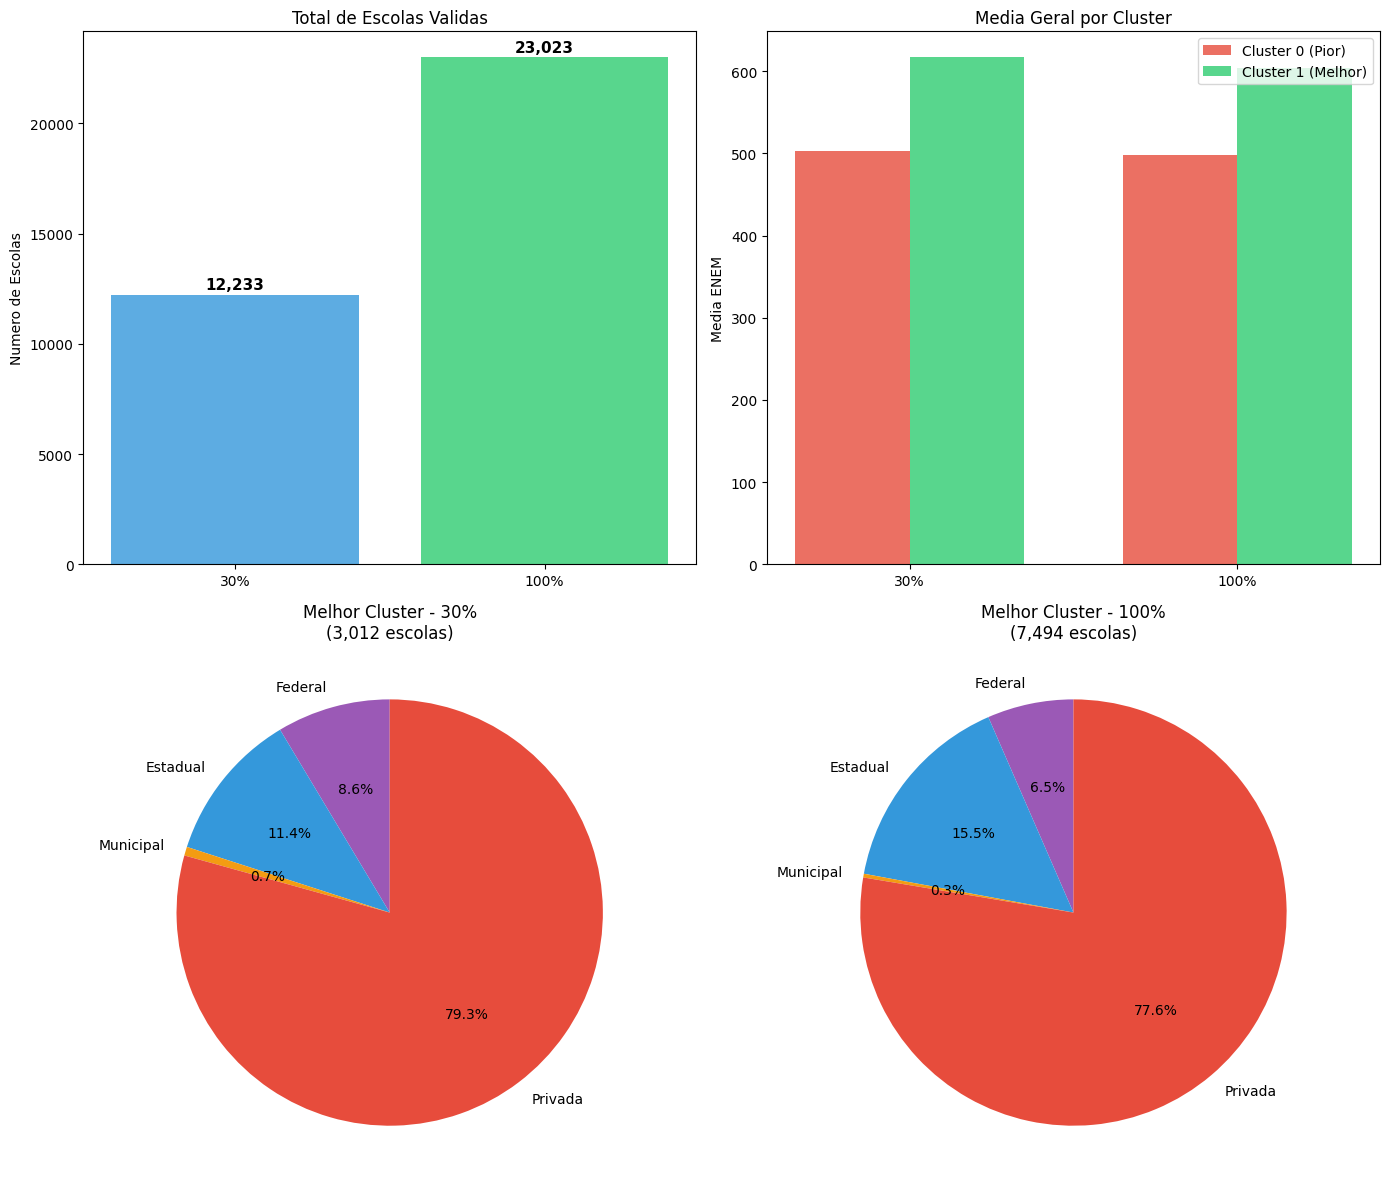

Figura salva em: C:\Users\leofs\Documents\ciencia_de_dados_2\enem_clustering\data\processed\comparacao_30_vs_100.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Distribuicao de escolas
ax1 = axes[0, 0]
x = ['30%', '100%']
totais = [stats_30['total_escolas'], stats_100['total_escolas']]
bars1 = ax1.bar(x, totais, color=['#3498db', '#2ecc71'], alpha=0.8)
ax1.set_ylabel('Numero de Escolas')
ax1.set_title('Total de Escolas Validas')
for bar, val in zip(bars1, totais):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{val:,}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Media por cluster
ax2 = axes[0, 1]
x_pos = np.arange(2)
width = 0.35
c0_medias = [stats_30.get('cluster_0_media', 0), stats_100.get('cluster_0_media', 0)]
c1_medias = [stats_30.get('cluster_1_media', 0), stats_100.get('cluster_1_media', 0)]

bars2a = ax2.bar(x_pos - width/2, c0_medias, width, label='Cluster 0 (Pior)', color='#e74c3c', alpha=0.8)
bars2b = ax2.bar(x_pos + width/2, c1_medias, width, label='Cluster 1 (Melhor)', color='#2ecc71', alpha=0.8)
ax2.set_ylabel('Media ENEM')
ax2.set_title('Media Geral por Cluster')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['30%', '100%'])
ax2.legend()

# 3. Composicao 30% - Melhor Cluster
ax3 = axes[1, 0]
deps = ['Federal', 'Estadual', 'Municipal', 'Privada']
cores = ['#9b59b6', '#3498db', '#f39c12', '#e74c3c']
vals_30 = [stats_30.get(f'{d}_melhor_pct', 0) for d in deps]
ax3.pie(vals_30, labels=deps, colors=cores, autopct='%1.1f%%', startangle=90)
ax3.set_title(f'Melhor Cluster - 30%\n({stats_30["cluster_1_count"]:,} escolas)')

# 4. Composicao 100% - Melhor Cluster
ax4 = axes[1, 1]
vals_100 = [stats_100.get(f'{d}_melhor_pct', 0) for d in deps]
ax4.pie(vals_100, labels=deps, colors=cores, autopct='%1.1f%%', startangle=90)
ax4.set_title(f'Melhor Cluster - 100%\n({stats_100["cluster_1_count"]:,} escolas)')

plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'comparacao_30_vs_100.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Figura salva em: {DATA_PROCESSED / "comparacao_30_vs_100.png"}')

## 6. Conclusoes

In [14]:
print('='*70)
print('ANALISE COMPARATIVA: 30% vs 100%')
print('='*70)
print()

# Calcular diferencas
diff_escolas = stats_100['total_escolas'] - stats_30['total_escolas']
diff_c0 = stats_100.get('cluster_0_media', 0) - stats_30.get('cluster_0_media', 0)
diff_c1 = stats_100.get('cluster_1_media', 0) - stats_30.get('cluster_1_media', 0)

privada_30 = stats_30.get('Privada_melhor_pct', 0)
privada_100 = stats_100.get('Privada_melhor_pct', 0)
estadual_30 = stats_30.get('Estadual_melhor_pct', 0)
estadual_100 = stats_100.get('Estadual_melhor_pct', 0)

print(f"1. AMOSTRAGEM:")
print(f"   - A amostra de 30% capturou {stats_30['total_escolas']:,} escolas")
print(f"   - O total de 100% tem     {stats_100['total_escolas']:,} escolas")
print(f"   - Diferenca: +{diff_escolas:,} escolas (+{diff_escolas/stats_30['total_escolas']*100:.1f}%)")
print()

print(f"2. DESEMPENHO MEDIO:")
print(f"   - Cluster 0: {diff_c0:+.2f} pontos de diferenca")
print(f"   - Cluster 1: {diff_c1:+.2f} pontos de diferenca")
print()

print(f"3. COMPOSICAO DO MELHOR CLUSTER:")
print(f"   - Escolas Privadas: {privada_30:.1f}% (30%) -> {privada_100:.1f}% (100%) [{privada_100-privada_30:+.1f}%]")
print(f"   - Escolas Estaduais: {estadual_30:.1f}% (30%) -> {estadual_100:.1f}% (100%) [{estadual_100-estadual_30:+.1f}%]")
print()

print(f"4. REPRESENTATIVIDADE:")
if abs(privada_100 - privada_30) < 5 and abs(estadual_100 - estadual_30) < 5:
    print(f"   ✓ A amostra de 30% e REPRESENTATIVA da populacao total")
    print(f"     (diferencas < 5% na composicao do melhor cluster)")
else:
    print(f"   ⚠ A amostra de 30% apresenta diferencas significativas")
    print(f"     Recomenda-se usar 100% para analises mais precisas")

print()
print('='*70)

ANALISE COMPARATIVA: 30% vs 100%

1. AMOSTRAGEM:
   - A amostra de 30% capturou 12,233 escolas
   - O total de 100% tem     23,023 escolas
   - Diferenca: +10,790 escolas (+88.2%)

2. DESEMPENHO MEDIO:
   - Cluster 0: -4.79 pontos de diferenca
   - Cluster 1: -13.33 pontos de diferenca

3. COMPOSICAO DO MELHOR CLUSTER:
   - Escolas Privadas: 79.3% (30%) -> 77.6% (100%) [-1.7%]
   - Escolas Estaduais: 11.4% (30%) -> 15.5% (100%) [+4.1%]

4. REPRESENTATIVIDADE:
   ✓ A amostra de 30% e REPRESENTATIVA da populacao total
     (diferencas < 5% na composicao do melhor cluster)

